# 03. MCMC Basics: Introduction to Bayesian Inference
This notebook introduces Markov Chain Monte Carlo (MCMC) for Bayesian inference using Numerics.

## What You'll Learn

- What is MCMC and why use it?
- Setting up priors
- Defining likelihood functions
- Running the RWMH (Random Walk Metropolis-Hastings) sampler
- Interpreting results (trace plots, posterior distributions)
- Burn-in and thinning

## When to Use MCMC

MCMC is useful when:
- You want to quantify uncertainty in parameters
- You have prior knowledge to incorporate
- You need full posterior distributions, not just point estimates
- Standard optimization methods are insufficient

## Setup

In [1]:
import pythonnet
pythonnet.load("coreclr")

import clr
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from System import Array, Double, Func
from System.Collections.Generic import List

# Load Numerics DLL
dll_path = Path(r"C:\GIT\Numerics\Numerics\bin\Debug\net8.0\Numerics.dll")
clr.AddReference(str(dll_path))

# Import MCMC and distribution classes
from Numerics.Sampling.MCMC import RWMH, MCMCResults, LogLikelihood, MCMCSampler
from Numerics.Distributions import Normal, Uniform, IUnivariateDistribution
from Numerics.Mathematics.LinearAlgebra import Matrix

print("✓ Setup complete")

✓ Setup complete


## Example 1: Estimating the Mean of a Normal Distribution

**Problem:** We have data from a Normal distribution with unknown mean μ and known standard deviation σ=15.

**Goal:** Estimate μ using Bayesian inference.

### Step 1: Generate Synthetic Data

Generated 50 observations
Sample mean: 96.62
Sample std: 13.86


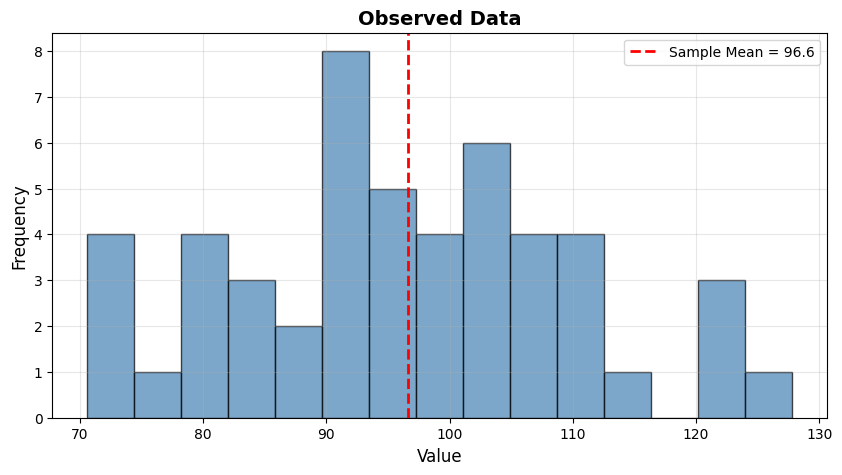

In [2]:
# True parameters (unknown to our inference)
true_mu = 100
true_sigma = 15

# Generate observed data
np.random.seed(42)
observed_data = np.random.normal(true_mu, true_sigma, size=50)

# Convert to .NET array
data_array = Array[Double](observed_data)

print(f"Generated {len(observed_data)} observations")
print(f"Sample mean: {np.mean(observed_data):.2f}")
print(f"Sample std: {np.std(observed_data):.2f}")

# Plot data
plt.figure(figsize=(10, 5))
plt.hist(observed_data, bins=15, alpha=0.7, color='steelblue', edgecolor='black')
plt.axvline(np.mean(observed_data), color='red', linestyle='--', linewidth=2, label=f'Sample Mean = {np.mean(observed_data):.1f}')
plt.xlabel('Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Observed Data', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Step 2: Define Priors

We need to specify prior distributions for our parameters. We'll use a weakly informative prior:
- μ ~ Uniform(50, 150) - we think μ is somewhere between 50 and 150

**Note:** In Numerics, we need to create a .NET List of distributions. Pay careful attention to how we define our lists below!

In [3]:
mu_prior = Uniform(50, 150)

# Create .NET List of priors
priors = List[IUnivariateDistribution]()
priors.Add(mu_prior)

print(f"Prior for μ: Uniform({mu_prior.Minimum}, {mu_prior.Maximum})")
print(f"Prior mean: {mu_prior.Mean:.2f}")

Prior for μ: Uniform(50.0, 150.0)
Prior mean: 100.00


### Step 3: Define the Log-Likelihood Function

The likelihood tells us how probable the data is given parameter values.

For our Normal distribution with known σ:
```
L(μ | data) = ∏ Normal(x | μ, σ=15)
```

For simplicity, we usually look at the log likelihood to turn the product into a summation.

```
log L(μ | data) = Σ log[Normal(x | μ, σ=15)]
```

**Important:** Numerics expects a function that:
1. Takes a .NET List[Double] of parameters
2. Returns a single double (the log-likelihood)

We must create this function in Python and then covert it to .NET function before passing it to our sampler.

In [4]:
# Define Python log-likelihood function
def log_likelihood(params):
    dist = Normal(params[0], 15)
    return dist.LogLikelihood(data_array)

# Wrap the Python function as a .NET Func
log_likelihood_func = LogLikelihood(log_likelihood)

print("✓ Log-likelihood function defined")

✓ Log-likelihood function defined


### Step 4: Run the MCMC Sampler

Now we can create and run the RWMH sampler!

In [5]:
# Create RWMH sampler
sampler = RWMH(priors, log_likelihood_func, Matrix(1))

# Optional: Configure sampler settings
# sampler.SampleSize = 5000  # Number of samples (default is good)
# sampler.BurnInSamples = 1000  # Burn-in period

sampler.Initialize = MCMCSampler.InitializationType.MAP

print("Running MCMC sampler...")
sampler.Sample()
print("✓ Sampling complete")

# Create results object for easy analysis
results = MCMCResults(sampler)

Running MCMC sampler...
✓ Sampling complete


### Step 5: Examine Results

Let's look at the trace plot to check if the chain has converged.

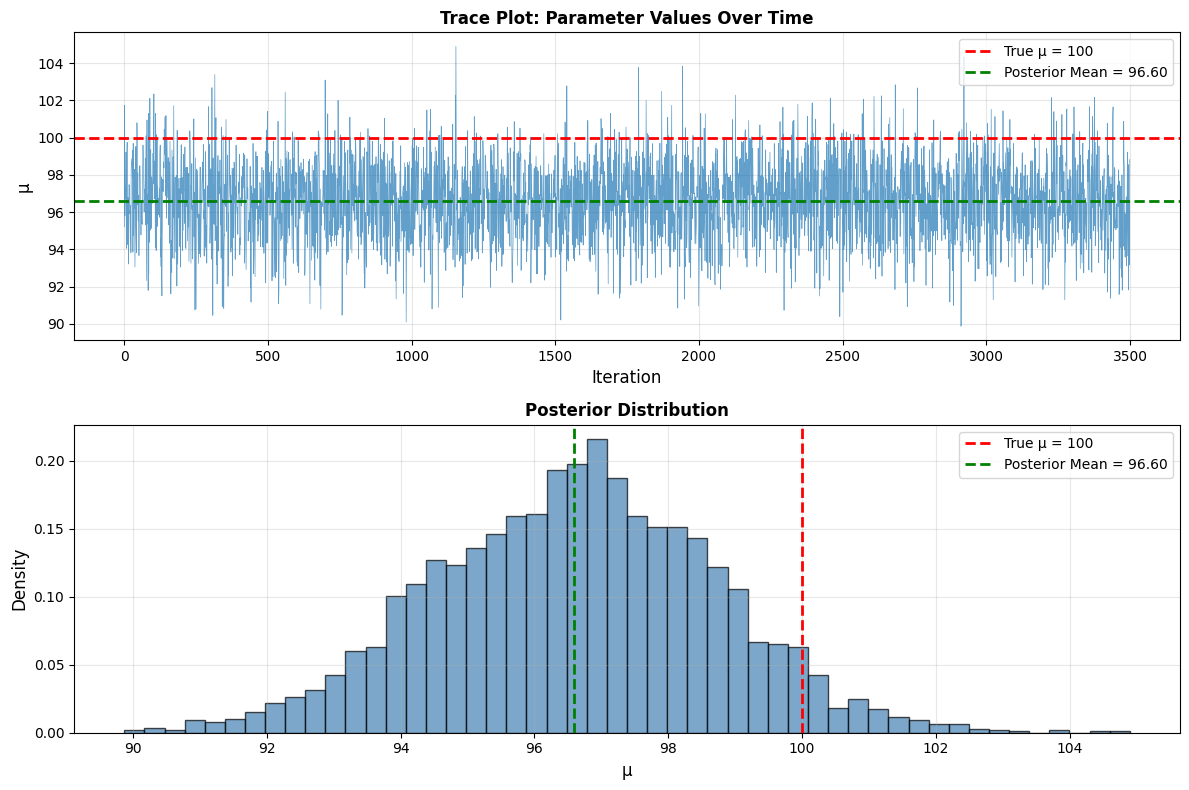

In [ ]:
# Extract samples for mu
# MarkovChains[i] = array of ParameterSets
# MarkovChains[i][0] = ParameterSet for first chain
# MarkovChains[i][0].Values[0] = first parameter value (mu)
mu_samples = [results.MarkovChains[0][i].Values[0] for i in range(len(results.MarkovChains[0]))]

# Create trace plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Trace plot
ax1.plot(mu_samples, linewidth=0.5, alpha=0.7)
ax1.axhline(true_mu, color='red', linestyle='--', linewidth=2, label=f'True μ = {true_mu}')
ax1.axhline(np.mean(mu_samples), color='green', linestyle='--', linewidth=2, label=f'Posterior Mean = {np.mean(mu_samples):.2f}')
ax1.set_xlabel('Iteration', fontsize=12)
ax1.set_ylabel('μ', fontsize=12)
ax1.set_title('Trace Plot: Parameter Values Over Time', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Posterior distribution
ax2.hist(mu_samples, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='black')
ax2.axvline(true_mu, color='red', linestyle='--', linewidth=2, label=f'True μ = {true_mu}')
ax2.axvline(np.mean(mu_samples), color='green', linestyle='--', linewidth=2, label=f'Posterior Mean = {np.mean(mu_samples):.2f}')
ax2.set_xlabel('μ', fontsize=12)
ax2.set_ylabel('Density', fontsize=12)
ax2.set_title('Posterior Distribution', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Step 6: Summary Statistics

Numerics provides convenient summary statistics through the MCMCResults object.

In [18]:
# Access summary statistics for parameter 0 (mu)
param_results = results.ParameterResults[0]
summary = param_results.SummaryStatistics

print("=" * 60)
print("POSTERIOR SUMMARY STATISTICS FOR μ")
print("=" * 60)
print(f"Mean:               {summary.Mean:.4f}")
print(f"Std Deviation:      {summary.StandardDeviation:.4f}")
print(f"Median:             {summary.Median:.4f}")
print(f"5th Percentile:     {summary.LowerCI:.4f}")
print(f"95th Percentile:    {summary.UpperCI:.4f}")
print(f"90% Credible Int:   [{summary.LowerCI:.2f}, {summary.UpperCI:.2f}]")
print("=" * 60)
print(f"\nTrue value:         {true_mu:.4f}")
print(f"Sample mean:        {np.mean(observed_data):.4f}")

POSTERIOR SUMMARY STATISTICS FOR μ
Mean:               96.5988
Std Deviation:      2.1282
Median:             96.5683
5th Percentile:     93.1465
95th Percentile:    100.1464
90% Credible Int:   [93.15, 100.15]

True value:         100.0000
Sample mean:        96.6179


## Example 2: Estimating Both Mean and Variance

Now let's estimate **both** μ and σ when both are unknown.

In [19]:
# Create priors for both parameters
mu_prior = Uniform(50, 150)
sigma_prior = Uniform(1, 50)

priors_both = List[IUnivariateDistribution]()
priors_both.Add(mu_prior)
priors_both.Add(sigma_prior)

# New log-likelihood function for both parameters
def log_likelihood_both(params):
    dist = Normal(params[0], params[1])
    return dist.LogLikelihood(data_array)

# Wrap the Python function as a .NET Func
log_likelihood_both_func = LogLikelihood(log_likelihood_both)

# Run sampler
print("Running MCMC for both parameters...")
sampler_both = RWMH(priors_both, log_likelihood_both_func, Matrix(2))
sampler_both.Initialize = MCMCSampler.InitializationType.MAP
sampler_both.Sample()
results_both = MCMCResults(sampler_both)
print("✓ Sampling complete")

Running MCMC for both parameters...
✓ Sampling complete


### Analyze Two-Parameter Results
Recall our true μ is 100 and our true σ is 15.

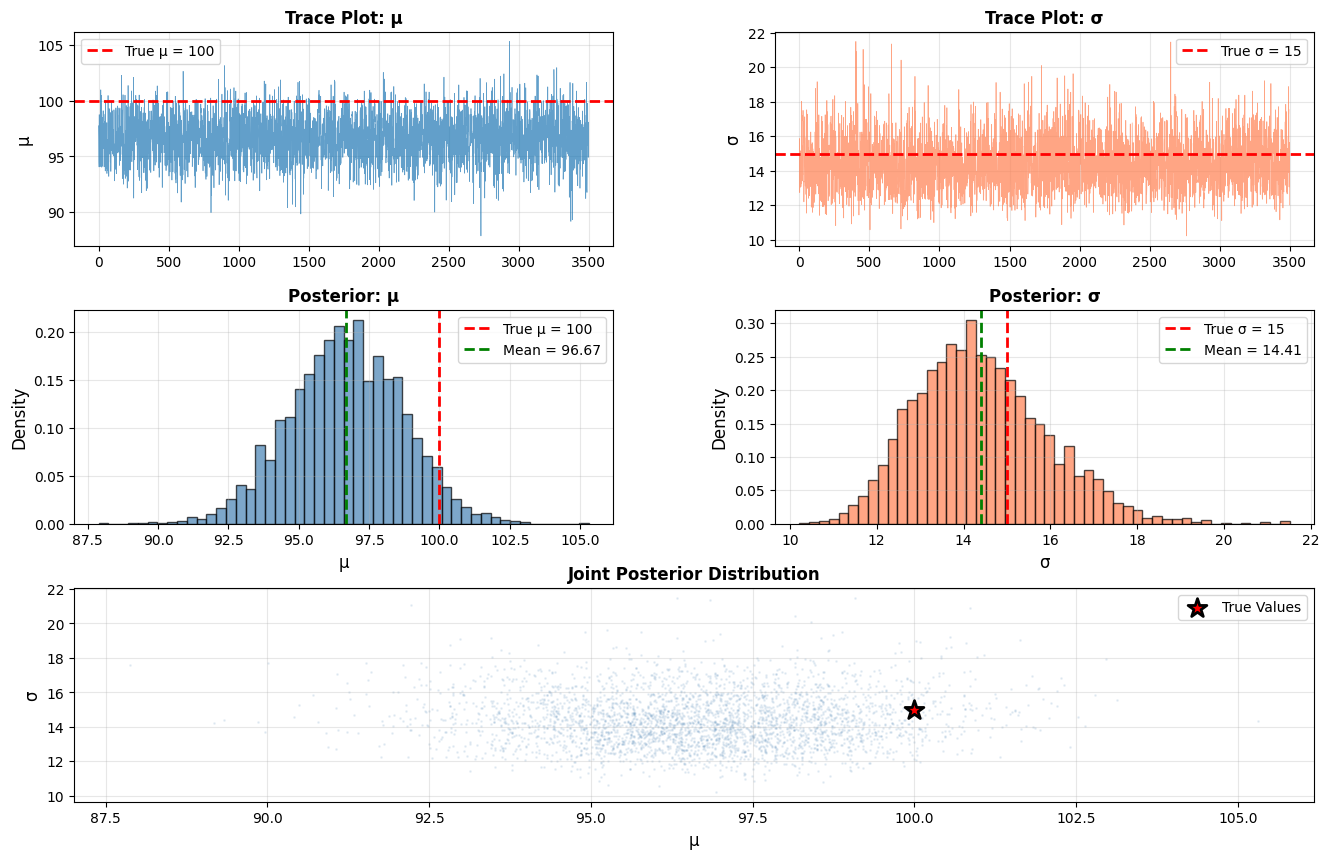


Posterior Summary:
Parameter    True       Mean       5%         95%       
μ            100.00     96.61      93.27      99.95     
σ            15.00      14.37      12.16      17.03     


In [ ]:
# Extract samples
mu_samples_2 = [results_both.MarkovChains[0][i].Values[0] for i in range(len(results.MarkovChains[0]))]
# For sigma we only need to change Values index to 1
sigma_samples_2 = [results_both.MarkovChains[0][i].Values[1] for i in range(len(results.MarkovChains[0]))]

# Create figure with multiple subplots
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# Trace plots
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(mu_samples_2, linewidth=0.5, alpha=0.7)
ax1.axhline(true_mu, color='red', linestyle='--', linewidth=2, label=f'True μ = {true_mu}')
ax1.set_ylabel('μ', fontsize=12)
ax1.set_title('Trace Plot: μ', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(sigma_samples_2, linewidth=0.5, alpha=0.7, color='coral')
ax2.axhline(true_sigma, color='red', linestyle='--', linewidth=2, label=f'True σ = {true_sigma}')
ax2.set_ylabel('σ', fontsize=12)
ax2.set_title('Trace Plot: σ', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Posterior distributions
ax3 = fig.add_subplot(gs[1, 0])
ax3.hist(mu_samples_2, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='black')
ax3.axvline(true_mu, color='red', linestyle='--', linewidth=2, label=f'True μ = {true_mu}')
ax3.axvline(np.mean(mu_samples_2), color='green', linestyle='--', linewidth=2, label=f'Mean = {np.mean(mu_samples_2):.2f}')
ax3.set_xlabel('μ', fontsize=12)
ax3.set_ylabel('Density', fontsize=12)
ax3.set_title('Posterior: μ', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

ax4 = fig.add_subplot(gs[1, 1])
ax4.hist(sigma_samples_2, bins=50, density=True, alpha=0.7, color='coral', edgecolor='black')
ax4.axvline(true_sigma, color='red', linestyle='--', linewidth=2, label=f'True σ = {true_sigma}')
ax4.axvline(np.mean(sigma_samples_2), color='green', linestyle='--', linewidth=2, label=f'Mean = {np.mean(sigma_samples_2):.2f}')
ax4.set_xlabel('σ', fontsize=12)
ax4.set_ylabel('Density', fontsize=12)
ax4.set_title('Posterior: σ', fontsize=12, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

# Joint posterior (scatter plot)
ax5 = fig.add_subplot(gs[2, :])
ax5.scatter(mu_samples_2, sigma_samples_2, alpha=0.1, s=1, color='steelblue')
ax5.scatter(true_mu, true_sigma, color='red', s=200, marker='*', edgecolor='black', linewidth=2, label='True Values', zorder=5)
ax5.set_xlabel('μ', fontsize=12)
ax5.set_ylabel('σ', fontsize=12)
ax5.set_title('Joint Posterior Distribution', fontsize=12, fontweight='bold')
ax5.legend()
ax5.grid(True, alpha=0.3)

plt.show()

# Print summary
print("\nPosterior Summary:")
print("=" * 60)
print(f"{'Parameter':<12} {'True':<10} {'Mean':<10} {'5%':<10} {'95%':<10}")
print("=" * 60)
print(f"{'μ':<12} {true_mu:<10.2f} {results_both.ParameterResults[0].SummaryStatistics.Mean:<10.2f} "
      f"{results_both.ParameterResults[0].SummaryStatistics.LowerCI:<10.2f} "
      f"{results_both.ParameterResults[0].SummaryStatistics.UpperCI:<10.2f}")
print(f"{'σ':<12} {true_sigma:<10.2f} {results_both.ParameterResults[1].SummaryStatistics.Mean:<10.2f} "
      f"{results_both.ParameterResults[1].SummaryStatistics.LowerCI:<10.2f} "
      f"{results_both.ParameterResults[1].SummaryStatistics.UpperCI:<10.2f}")
print("=" * 60)

## Understanding Burn-in and Thinning

### Burn-in
The initial samples before the chain converges. Sometimes, it can take a while for the chain to explore the posterior space and converge. These initial samples can be semmingly random and misleading and should be discarded.

### Thinning
Taking every nth sample to reduce autocorrelation.

Let's visualize these concepts:

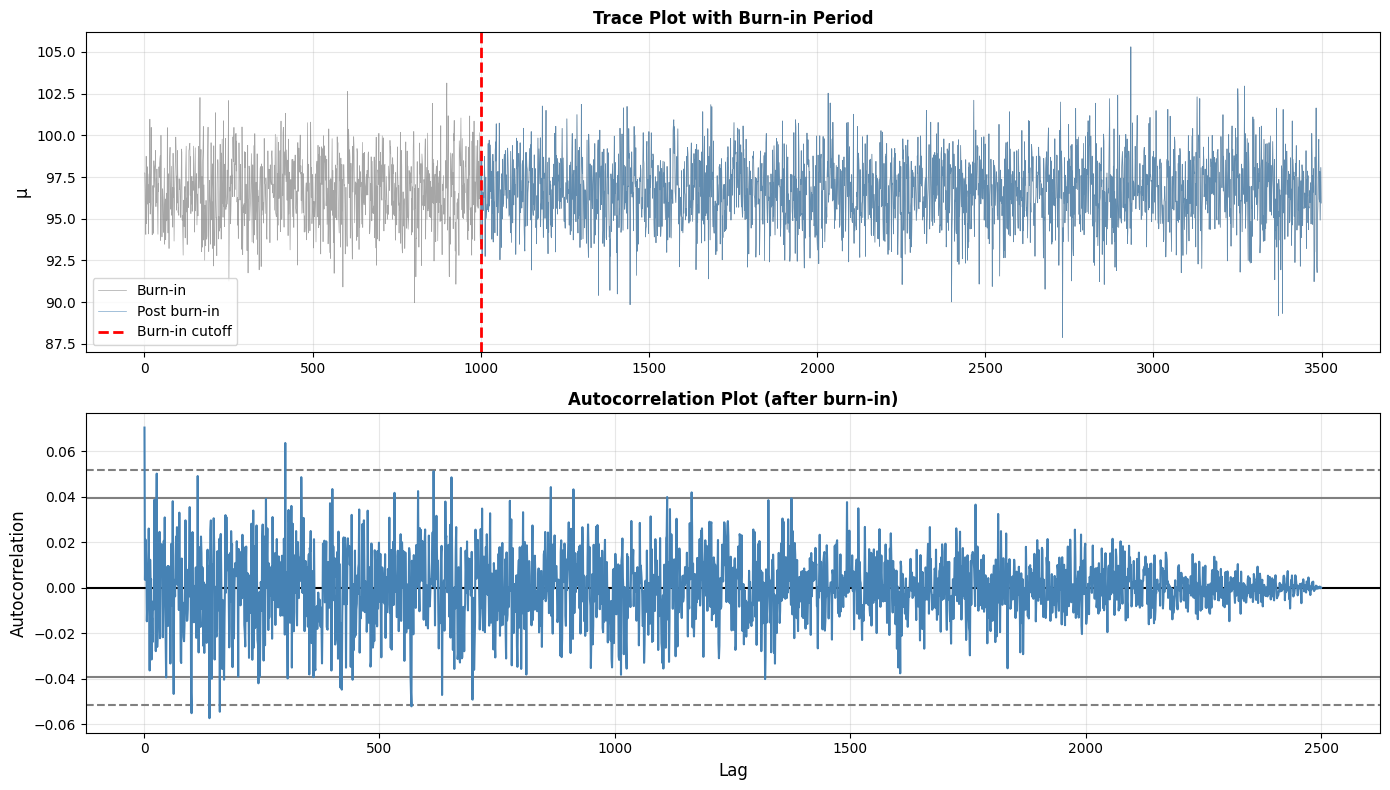


Effective sample size after removing burn-in: 2500


In [25]:
# Plot with burn-in highlighted
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

burn_in = 1000  # First 1000 samples

# Full trace
ax1.plot(mu_samples_2, linewidth=0.5, alpha=0.7, color='gray', label='Burn-in')
ax1.plot(range(burn_in, len(mu_samples_2)), mu_samples_2[burn_in:], linewidth=0.5, alpha=0.7, color='steelblue', label='Post burn-in')
ax1.axvline(burn_in, color='red', linestyle='--', linewidth=2, label=f'Burn-in cutoff')
ax1.set_ylabel('μ', fontsize=12)
ax1.set_title('Trace Plot with Burn-in Period', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Autocorrelation
from pandas.plotting import autocorrelation_plot
mu_series = pd.Series(mu_samples_2[burn_in:])
autocorrelation_plot(mu_series, ax=ax2, color='steelblue')
ax2.set_xlabel('Lag', fontsize=12)
ax2.set_ylabel('Autocorrelation', fontsize=12)
ax2.set_title('Autocorrelation Plot (after burn-in)', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nEffective sample size after removing burn-in: {len(mu_samples_2) - burn_in}")

## Summary

### What is MCMC?
- **Goal:** Sample from a probability distribution we can't compute directly
- **Method:** Create a Markov chain whose stationary distribution is our target
- **Result:** Samples that approximate the posterior distribution

### RWMH Algorithm
1. Start with initial parameter values
2. Propose a new value (random walk)
3. Calculate acceptance ratio
4. Accept or reject based on ratio
5. Repeat thousands of times

### Interpreting Results
- **Trace plot:** Should look like "fuzzy caterpillar" (good mixing)
- **Posterior:** Your updated beliefs after seeing data
- **Credible interval:** Bayesian analog of confidence interval

### Good Practice
✓ Check convergence visually (trace plots)  
✓ Remove burn-in samples  
✓ Consider thinning for autocorrelated samples  
✓ Run multiple chains (see notebook 05)  
✓ Use informative priors when you have domain knowledge